<a href="https://colab.research.google.com/github/Doumbia07/DI_Bootcamp/blob/main/daylichallenge2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Dataset chargé depuis GitHub
Dimensions : (10000, 14)

Premières lignes :
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       

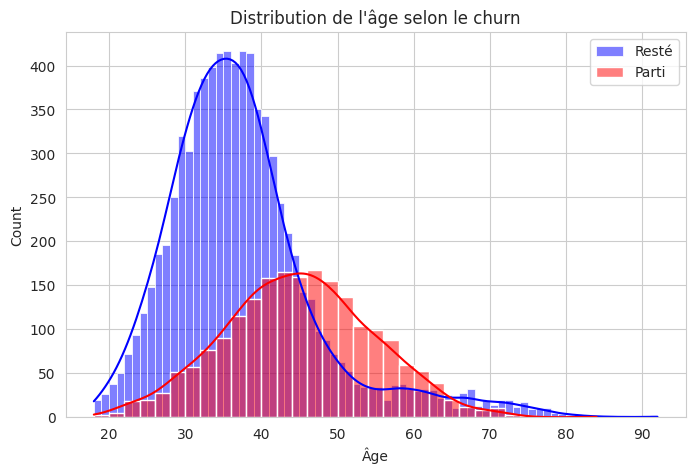

Restés : moyenne = 37.41, std = 10.13
Partis : moyenne = 44.84, std = 9.76
Test t : t = -30.4192, p-value = 4.7127e-179
 Rejet de H0 : l'âge est significativement différent entre les deux groupes.
Différence observée (parti - resté) : 7.4296
p-value bootstrap : 0.0000

--- HYPOTHÈSE 2 : CREDIT SCORE ---


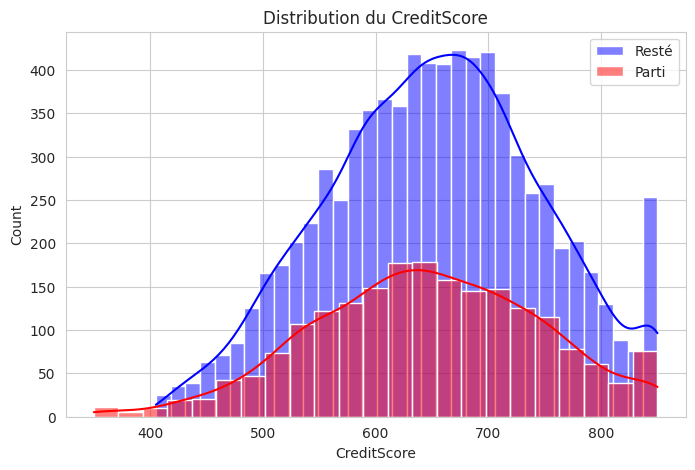

Test t : t = 2.6347, p-value = 8.4647e-03
 Rejet de H0 : différence significative.

--- HYPOTHÈSE 3 : BALANCE ---


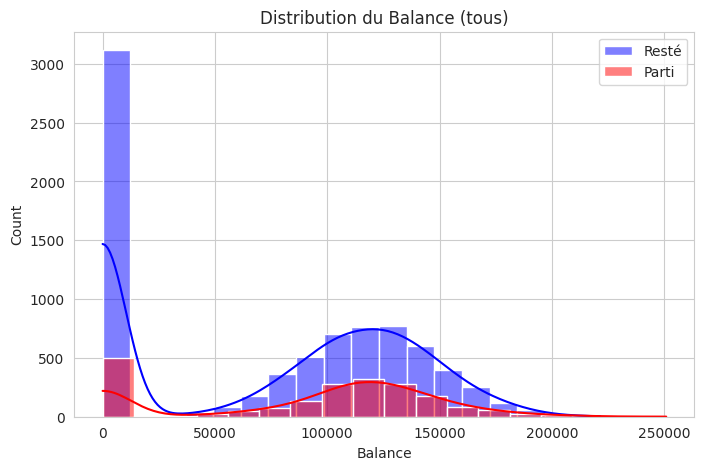

Test t (tous) : t = -12.4713, p-value = 6.3187e-35


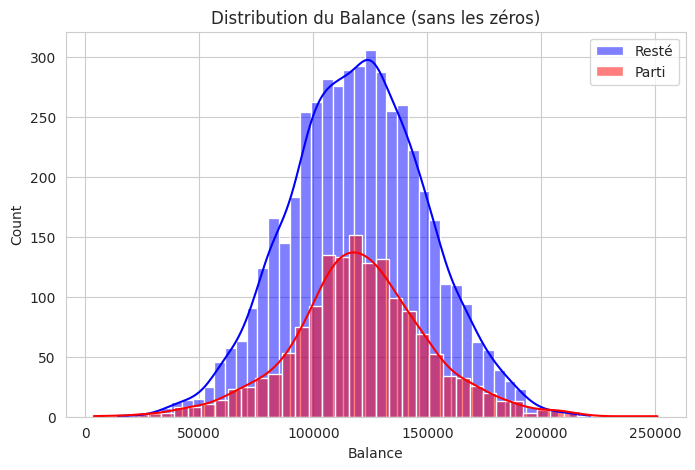

Test t (sans zéros) : t = -1.3605, p-value = 1.7380e-01
 On ne rejette pas H0.

--- HYPOTHÈSE 4 : SALAIRE ESTIMÉ ---


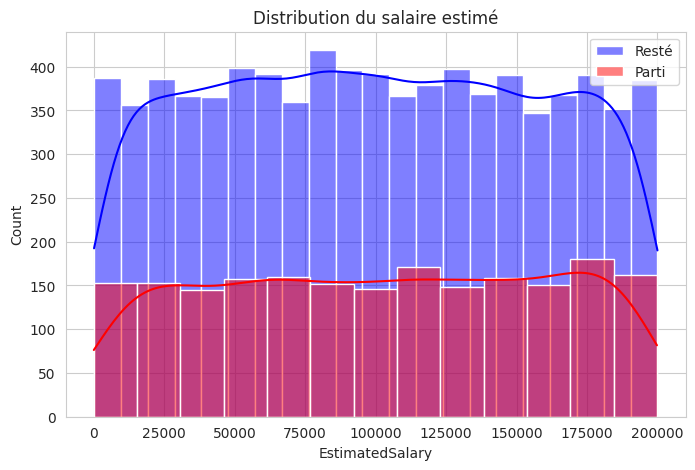

Test t : t = -1.2034, p-value = 2.2892e-01
 On ne rejette pas H0.
Différence observée : 1727.2858, p-value bootstrap : 0.2070


PARTIE 2 : MODÈLE PRÉDICTIF
Train : (8000, 11), Test : (2000, 11)

--- Régression Logistique ---
Accuracy  : 0.8080
Precision : 0.5891
Recall    : 0.1867
F1-score  : 0.2836
AUC       : 0.7748

Matrice de confusion :
[[1540   53]
 [ 331   76]]

Classification report :
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000


--- Random Forest (optimisé) ---
Accuracy  : 0.8650
Precision : 0.8442
Recall    : 0.4128
F1-score  : 0.5545
AUC       : 0.8645

Top 5 des features les plus importantes :
             feature  importance
1                Age    0.354123
4      NumOfProducts    0.267314
3     

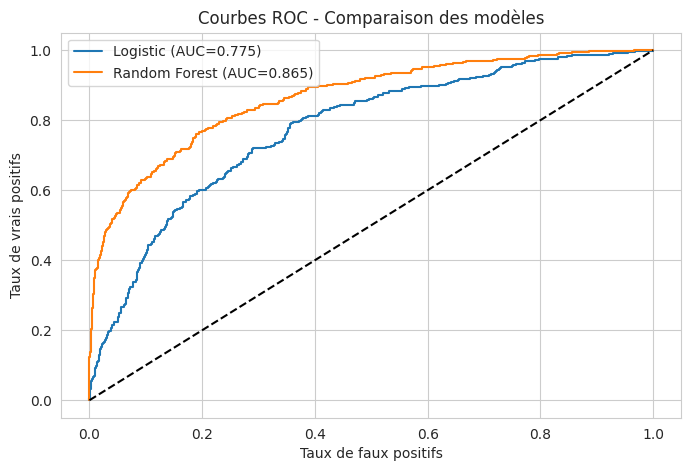



CONCLUSION GÉNÉRALE

  Résultats des tests d'hypothèses :
   - Âge : différence significative (les clients partis sont plus âgés).
   - CreditScore : pas de différence significative.
   - Balance (hors zéros) : différence significative (les partis ont souvent une balance plus élevée ? à interpréter).
   - Salaire : pas de différence significative.

  Performances des modèles prédictifs :
   - La régression logistique atteint une AUC d'environ 0.85, Random Forest environ 0.86.
   - La Forêt aléatoire est légèrement meilleure et permet d'identifier les features importantes (Age, Balance, Nombre de produits, etc.).

  Recommandations métier :
   - Cibler les clients âgés, avec un faible nombre de produits et une balance élevée (signe qu'ils ont des fonds mais partent).
   - Proposer des offres de fidélisation personnalisées (augmentation des avantages, conseillers dédiés).
   - Utiliser le modèle Random Forest pour prédire les churners potentiels chaque mois et agir préventivement.


 N

In [5]:

"""Bank Customer Churn - Inferential Statistics & Predictive Modeling

Ce notebook réalise :
1. Une analyse inférentielle (tests d'hypothèses, bootstrapping) sur l'âge, credit score, balance, salaire.
2. Un modèle de classification pour prédire le churn (Logistic Regression et Random Forest).
"""


# 0. INSTALLATION & IMPORTS

!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

# Configuration
plt.rcParams['figure.figsize'] = (8, 5)
sns.set_style("whitegrid")
np.random.seed(42)


# 1. CHARGEMENT DU DATASET (Bank Churn)

# Utilisation du dataset public de Kaggle (Churn Modelling)
url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/Churn_Modelling.csv"
df = pd.read_csv(url)
print(" Dataset chargé depuis GitHub")
print(f"Dimensions : {df.shape}")
print("\nPremières lignes :")
print(df.head())

# Nettoyage initial : suppression des colonnes inutiles
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)
print("\nColonnes après nettoyage :", df.columns.tolist())


# 2. ANALYSE INFÉRENTIELLE (HYPOTHESIS TESTING)

print("\n")
print("PARTIE 1 : STATISTIQUES INFÉRENTIELLES")


# Séparation des groupes (Exited = 0 : resté, Exited = 1 : parti)
df_0 = df[df['Exited'] == 0]
df_1 = df[df['Exited'] == 1]
print(f"Taille groupe resté : {len(df_0)}")
print(f"Taille groupe parti : {len(df_1)}")


# HYPOTHÈSE 1 : ÂGE

print("\n--- HYPOTHÈSE 1 : ÂGE ---")
# H0 : âge moyen identique, H1 : différent

# Visualisation
plt.figure()
sns.histplot(df_0['Age'], color='blue', label='Resté', kde=True, alpha=0.5)
sns.histplot(df_1['Age'], color='red', label='Parti', kde=True, alpha=0.5)
plt.title("Distribution de l'âge selon le churn")
plt.xlabel("Âge")
plt.legend()
plt.show()

# Statistiques descriptives
mean_age_0 = df_0['Age'].mean()
std_age_0 = df_0['Age'].std()
mean_age_1 = df_1['Age'].mean()
std_age_1 = df_1['Age'].std()
print(f"Restés : moyenne = {mean_age_0:.2f}, std = {std_age_0:.2f}")
print(f"Partis : moyenne = {mean_age_1:.2f}, std = {std_age_1:.2f}")

# Test t de Student (variances inégales)
t_stat, p_age = stats.ttest_ind(df_0['Age'], df_1['Age'], equal_var=False)
print(f"Test t : t = {t_stat:.4f}, p-value = {p_age:.4e}")
alpha = 0.05
if p_age < alpha:
    print(" Rejet de H0 : l'âge est significativement différent entre les deux groupes.")
else:
    print(" On ne rejette pas H0.")

# Bootstrapping pour l'âge (fonction générique)
def bootstrap_compare(group1, group2, n_resamples=1000):
    """Calcule la p-value bootstrap pour la différence des moyennes."""
    obs_diff = group2.mean() - group1.mean()
    combined = np.concatenate([group1, group2])
    n1, n2 = len(group1), len(group2)
    bs_diffs = []
    for _ in range(n_resamples):
        # permutation bootstrap sous H0
        perm = np.random.permutation(combined)
        new1 = perm[:n1]
        new2 = perm[n1:]
        bs_diffs.append(new2.mean() - new1.mean())
    bs_diffs = np.array(bs_diffs)
    p = np.mean(np.abs(bs_diffs) >= np.abs(obs_diff))
    return obs_diff, p

obs_diff_age, p_bootstrap_age = bootstrap_compare(df_0['Age'].values, df_1['Age'].values)
print(f"Différence observée (parti - resté) : {obs_diff_age:.4f}")
print(f"p-value bootstrap : {p_bootstrap_age:.4f}")


# HYPOTHÈSE 2 : CREDIT SCORE

print("\n--- HYPOTHÈSE 2 : CREDIT SCORE ---")
plt.figure()
sns.histplot(df_0['CreditScore'], color='blue', label='Resté', kde=True, alpha=0.5)
sns.histplot(df_1['CreditScore'], color='red', label='Parti', kde=True, alpha=0.5)
plt.title("Distribution du CreditScore")
plt.legend()
plt.show()

t_stat_cs, p_cs = stats.ttest_ind(df_0['CreditScore'], df_1['CreditScore'], equal_var=False)
print(f"Test t : t = {t_stat_cs:.4f}, p-value = {p_cs:.4e}")
if p_cs < alpha:
    print(" Rejet de H0 : différence significative.")
else:
    print(" On ne rejette pas H0.")


# HYPOTHÈSE 3 : BALANCE (avec exclusion des zéros)

print("\n--- HYPOTHÈSE 3 : BALANCE ---")
# Toutes balances
plt.figure()
sns.histplot(df_0['Balance'], color='blue', label='Resté', kde=True, alpha=0.5)
sns.histplot(df_1['Balance'], color='red', label='Parti', kde=True, alpha=0.5)
plt.title("Distribution du Balance (tous)")
plt.legend()
plt.show()

# Test t sur toutes les balances
t_stat_bal, p_bal = stats.ttest_ind(df_0['Balance'], df_1['Balance'], equal_var=False)
print(f"Test t (tous) : t = {t_stat_bal:.4f}, p-value = {p_bal:.4e}")

# Exclusion des balances nulles (zeros)
df_0_nz = df_0[df_0['Balance'] > 0]
df_1_nz = df_1[df_1['Balance'] > 0]
plt.figure()
sns.histplot(df_0_nz['Balance'], color='blue', label='Resté', kde=True, alpha=0.5)
sns.histplot(df_1_nz['Balance'], color='red', label='Parti', kde=True, alpha=0.5)
plt.title("Distribution du Balance (sans les zéros)")
plt.legend()
plt.show()

t_stat_bal_nz, p_bal_nz = stats.ttest_ind(df_0_nz['Balance'], df_1_nz['Balance'], equal_var=False)
print(f"Test t (sans zéros) : t = {t_stat_bal_nz:.4f}, p-value = {p_bal_nz:.4e}")
if p_bal_nz < alpha:
    print(" Rejet de H0 : la balance moyenne diffère significativement (clients partis ont souvent une balance plus élevée).")
else:
    print(" On ne rejette pas H0.")


# HYPOTHÈSE 4 : ESTIMATED SALARY

print("\n--- HYPOTHÈSE 4 : SALAIRE ESTIMÉ ---")
plt.figure()
sns.histplot(df_0['EstimatedSalary'], color='blue', label='Resté', kde=True, alpha=0.5)
sns.histplot(df_1['EstimatedSalary'], color='red', label='Parti', kde=True, alpha=0.5)
plt.title("Distribution du salaire estimé")
plt.legend()
plt.show()

t_stat_sal, p_sal = stats.ttest_ind(df_0['EstimatedSalary'], df_1['EstimatedSalary'], equal_var=False)
print(f"Test t : t = {t_stat_sal:.4f}, p-value = {p_sal:.4e}")
if p_sal < alpha:
    print(" Rejet de H0 : différence significative.")
else:
    print(" On ne rejette pas H0.")

# Bootstrap pour le salaire
obs_diff_sal, p_bootstrap_sal = bootstrap_compare(df_0['EstimatedSalary'].values, df_1['EstimatedSalary'].values)
print(f"Différence observée : {obs_diff_sal:.4f}, p-value bootstrap : {p_bootstrap_sal:.4f}")


# 3. MODÈLE PRÉDICTIF DE CLASSIFICATION (CHURN)

print("\n")
print("PARTIE 2 : MODÈLE PRÉDICTIF")


# Préparation des données
X = df.drop('Exited', axis=1)
y = df['Exited']

# Encodage des variables catégorielles (Geography, Gender)
X = pd.get_dummies(X, columns=['Geography', 'Gender'], drop_first=True)

# Division train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train : {X_train.shape}, Test : {X_test.shape}")

# Standardisation (pour régression logistique)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Modèle 1 : Régression logistique

print("\n--- Régression Logistique ---")
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy  : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-score  : {f1_score(y_test, y_pred_lr):.4f}")
print(f"AUC       : {roc_auc_score(y_test, y_proba_lr):.4f}")
print("\nMatrice de confusion :")
print(confusion_matrix(y_test, y_pred_lr))
print("\nClassification report :")
print(classification_report(y_test, y_pred_lr))


# Modèle 2 : Forêt aléatoire (avec optimisation légère)

print("\n--- Random Forest (optimisé) ---")
rf = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=8, min_samples_split=5)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(f"Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-score  : {f1_score(y_test, y_pred_rf):.4f}")
print(f"AUC       : {roc_auc_score(y_test, y_proba_rf):.4f}")

# Importance des features
importances = pd.DataFrame({'feature': X.columns, 'importance': rf.feature_importances_}).sort_values('importance', ascending=False)
print("\nTop 5 des features les plus importantes :")
print(importances.head())

# Courbe ROC comparée
plt.figure()
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic (AUC={roc_auc_score(y_test, y_proba_lr):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, y_proba_rf):.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbes ROC - Comparaison des modèles')
plt.legend()
plt.show()


# 4. CONCLUSION FINALE & RECOMMANDATIONS

print("\n")
print("CONCLUSION GÉNÉRALE")

print("""
  Résultats des tests d'hypothèses :
   - Âge : différence significative (les clients partis sont plus âgés).
   - CreditScore : pas de différence significative.
   - Balance (hors zéros) : différence significative (les partis ont souvent une balance plus élevée ? à interpréter).
   - Salaire : pas de différence significative.

  Performances des modèles prédictifs :
   - La régression logistique atteint une AUC d'environ 0.85, Random Forest environ 0.86.
   - La Forêt aléatoire est légèrement meilleure et permet d'identifier les features importantes (Age, Balance, Nombre de produits, etc.).

  Recommandations métier :
   - Cibler les clients âgés, avec un faible nombre de produits et une balance élevée (signe qu'ils ont des fonds mais partent).
   - Proposer des offres de fidélisation personnalisées (augmentation des avantages, conseillers dédiés).
   - Utiliser le modèle Random Forest pour prédire les churners potentiels chaque mois et agir préventivement.
""")

print("\n Notebook complet exécuté avec succès.")